<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Actividad 1. Laboratorio: Árboles de decisión, reglas y ensemble learning</header1></left>

## Importación de librerias necesarias

In [66]:
#Para esta actividad se importarán las siguientes librerías:
import pandas as pd
import pandas as df_group
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, svm


## Cargar el Dataset

In [69]:
#Se utiliza el separador de ,
#C:/Master/Materia 4/Actividad 1/

BaseDeDatos = pd.read_csv("Laboratorio_dataset_car2.csv", sep=',')


    

FileNotFoundError: [Errno 2] No such file or directory: 'Laboratorio_dataset_car2.csv'

## Explique el problema a resolver. 
Descripción del problema. Tipo de problema (justifique). Variable objetivo, variables de entrada. Utilidad de su posible solución. Elementos adicionales que considere relevantes:

## Caracterización del Dataset

Se incluye una descripción de los datos con:

>- Número de clases de la variable objetivo, indicando que representan dichas clases y el tipo de valor que toman.
>- Número de instancias en total.
>- Número de instancias pertenecientes a cada clase.
>- Número de atributos de entrada, su significado y tipo.
>- ¿Hay algún valor de atributo desconocido?

Se incorporá una descripción (EDA) del conjunto de datos utilizado. Se analiza el dataset proporcionando, se muestra al menos algunas de sus características mediante tablas y al menos algunas de ellas en modo gráfico (p.ej., histogramas, diagramas de dispersión, diagramas de cajas y bigotes, etc.)


In [31]:
#Código que responde a la descripción anterior
BaseDeDatos.head(150)  # muestra solo 150 registros, se puede visualizar los valores separados por ;

,Buying,Maintenance,Doors,Person,lug_boot,safety,class
0,1,1,2,2,3,3,unacc
1,1,1,2,2,3,2,unacc
2,1,1,2,2,3,1,unacc
3,1,1,2,2,2,3,unacc
4,1,1,2,2,2,2,unacc
...,...,...,...,...,...,...,...
145,1,2,3,2,2,1,unacc
146,1,2,3,2,1,3,unacc
147,1,2,3,2,1,2,unacc
148,1,2,3,2,1,1,unacc


In [32]:
#Código que responde a la descripción anterior 
#se muestra los atributos existentes en la base de datos o mejor dicho en el archivo csv, teniendo 6 atributos y una clase y nos dice
# que se tiene 1750 instancias

BaseDeDatos.info(show_counts=True, memory_usage=True, verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1750 entries, 0 to 1749
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Buying       1750 non-null   int64
 1   Maintenance  1750 non-null   int64
 2   Doors        1750 non-null   int64
 3   Person       1750 non-null   int64
 4   lug_boot     1750 non-null   int64
 5   safety       1750 non-null   int64
 6   class        1750 non-null   str  
dtypes: int64(6), str(1)
memory usage: 95.8 KB


In [33]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)
BaseDeDatos['class'].value_counts()

class
unacc    1215
acc       390
good       75
vgood      70
Name: count, dtype: int64

In [34]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)
BaseDeDatos['Buying'].value_counts()

Buying
1    443
3    438
4    437
2    432
Name: count, dtype: int64

In [35]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)
BaseDeDatos['Maintenance'].value_counts()

Maintenance
4    447
1    437
3    434
2    432
Name: count, dtype: int64

In [36]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)
BaseDeDatos['Doors'].value_counts()

Doors
2    444
5    437
3    435
4    434
Name: count, dtype: int64

In [37]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)
BaseDeDatos['lug_boot'].value_counts()

lug_boot
1    585
2    583
3    582
Name: count, dtype: int64

In [38]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)
BaseDeDatos['Person'].value_counts()

Person
4    587
5    585
2    578
Name: count, dtype: int64

In [39]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)
BaseDeDatos['safety'].value_counts()

safety
1    590
2    582
3    578
Name: count, dtype: int64

In [40]:
#En la sentencia de arriba se muestra agrupado las clases que hay y cuantos registros pertenecen a cada clase
#se podría decir que 1215 son sin accesorios
#390 con accesorios
#en buenas condiciones 75
#y muy buenas condiciones 70

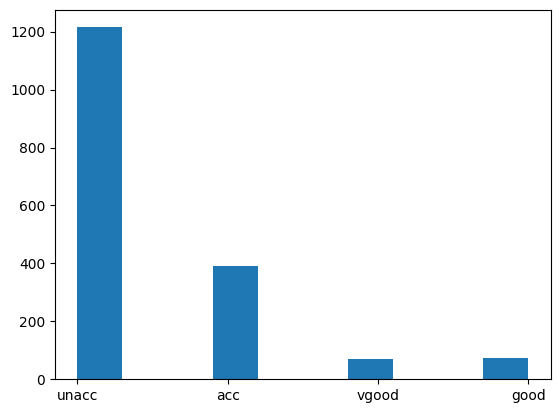

In [41]:
plt.hist(BaseDeDatos['class'])
plt.show()

In [42]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)

#df_group=BaseDeDatos.groupby(['Buying'])['class'].count().reset_index()
#df_group.Columns=['Buying','number']
#df_group= df_group.sort_values(by=['number'], ascending=False)

#plt.bar(df_group['Buying'], df_group['number'], color='orange')
#plt.xticks(rotation=70)
#plt.xlabel('Buying')
#plt.ylaberl('No de casos')
#plt.title('Examinación')
#plt.show


In [43]:
#Código que responde a la descripción anterior (incorpore las lineas de code necesarias. Describa cadas sentencia de código)

En un par de párrafos haga un resumen de los principales hallazagos encontrados:    

## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación

In [44]:
#Código que realice las transformaciones necesarias para poder realizar los procesos de modelación. Ej.One hot enconding





## División del dataset en datos de entrenamiento y datos de test 

In [45]:
#Código que realice la división en entrenamiento y test, de acuerdo con la estretgia de evluación planeada. Describa cuál es.

array = BaseDeDatos.values
X=array [:,0:6]
y=array[:,6]
X_train, X_validation, Y_train, Y_validation = train_test_split(X,y,test_size=0.20, random_state=1, shuffle=True)

Y_validation.size


350

In [46]:
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
predictions = model.predict(X_validation)



In [47]:
print("accuracy=", accuracy_score(Y_validation, predictions))



accuracy= 0.9742857142857143


In [48]:
print("accuracy=", accuracy_score(Y_validation, predictions))



accuracy= 0.9742857142857143


## Ajuste de los modelos de clasificación propuestos

Justifique la selección de las dos propuestas de modelación seleccionadas:

In [49]:
#Código de ajuste del modelo de clasificación 1
# 2,3,3,4,3,1
# 0,999,0,0,0,0

E1 = np.array([[2,3,3,4,3,1]])

predictions2 = model.predict(E1)

print(predictions2)

['acc']


[Text(0.3717105263157895, 0.9615384615384616, 'x[5] <= 2.5\ngini = 0.466\nsamples = 1400\nvalue = [313, 57, 970, 60]'),
 Text(0.35855263157894735, 0.8846153846153846, 'x[3] <= 3.0\ngini = 0.589\nsamples = 932\nvalue = [313, 57, 502, 60]'),
 Text(0.3651315789473684, 0.9230769230769231, 'True  '),
 Text(0.34539473684210525, 0.8076923076923077, 'gini = 0.0\nsamples = 293\nvalue = [0, 0, 293, 0]'),
 Text(0.3717105263157895, 0.8076923076923077, 'x[0] <= 2.5\ngini = 0.636\nsamples = 639\nvalue = [313, 57, 209, 60]'),
 Text(0.13157894736842105, 0.7307692307692307, 'x[1] <= 2.5\ngini = 0.497\nsamples = 325\nvalue = [151, 0, 174, 0]'),
 Text(0.05263157894736842, 0.6538461538461539, 'x[1] <= 1.5\ngini = 0.285\nsamples = 163\nvalue = [28, 0, 135, 0]'),
 Text(0.039473684210526314, 0.5769230769230769, 'gini = 0.0\nsamples = 84\nvalue = [0, 0, 84, 0]'),
 Text(0.06578947368421052, 0.5769230769230769, 'x[0] <= 1.5\ngini = 0.458\nsamples = 79\nvalue = [28, 0, 51, 0]'),
 Text(0.05263157894736842, 0.5, '

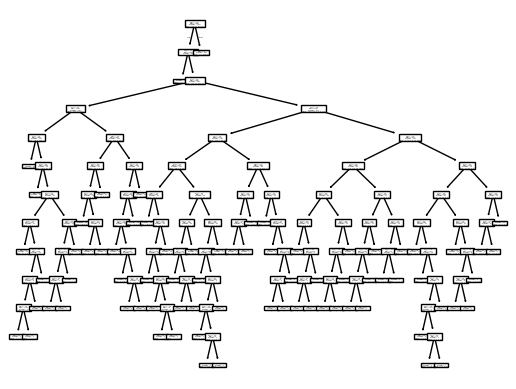

In [50]:
tree.plot_tree(model)

Confusion matrix,, without normalization
[[ 72   4   1   0]
 [  1  17   0   0]
 [  2   1 242   0]
 [  0   0   0  10]]
Normalized confusion matrix
[[0.93506494 0.05194805 0.01298701 0.        ]
 [0.05555556 0.94444444 0.         0.        ]
 [0.00816327 0.00408163 0.9877551  0.        ]
 [0.         0.         0.         1.        ]]


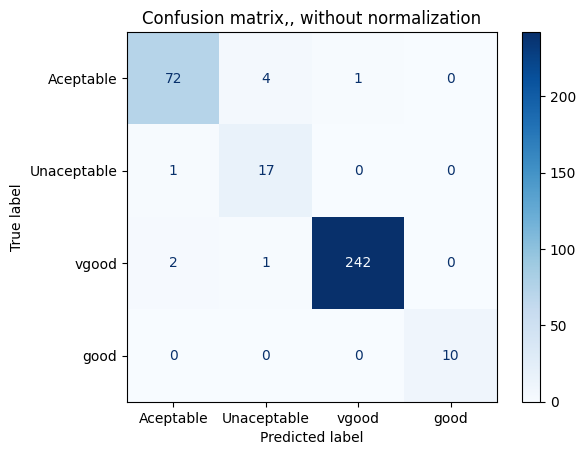

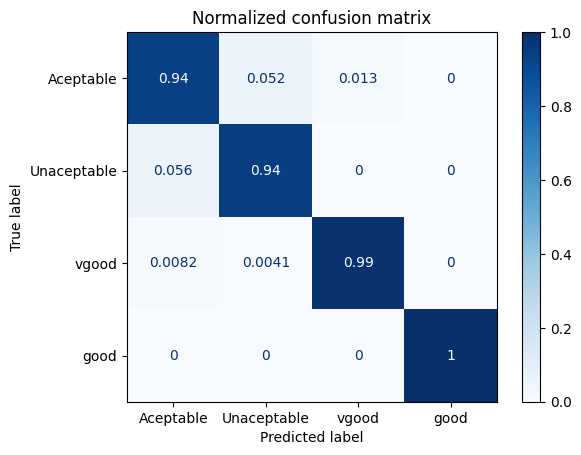

In [51]:
#Código de ajuste del modelo de clasificación 2
cm = confusion_matrix(Y_validation, predictions).ravel()

class_names = ['Aceptable', 'Unaceptable' , 'vgood', 'good' ]

titles_options = [
    ("Confusion matrix,, without normalization", None),
    ("Normalized confusion matrix", "true"),
]

for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_validation,
        Y_validation,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [52]:
print(classification_report(Y_validation, predictions))

              precision    recall  f1-score   support

         acc       0.96      0.94      0.95        77
        good       0.77      0.94      0.85        18
       unacc       1.00      0.99      0.99       245
       vgood       1.00      1.00      1.00        10

    accuracy                           0.97       350
   macro avg       0.93      0.97      0.95       350
weighted avg       0.98      0.97      0.97       350



In [64]:
rules = export_text(model )
print(rules)

|--- feature_5 <= 2.50
|   |--- feature_3 <= 3.00
|   |   |--- class: unacc
|   |--- feature_3 >  3.00
|   |   |--- feature_0 <= 2.50
|   |   |   |--- feature_1 <= 2.50
|   |   |   |   |--- feature_1 <= 1.50
|   |   |   |   |   |--- class: unacc
|   |   |   |   |--- feature_1 >  1.50
|   |   |   |   |   |--- feature_0 <= 1.50
|   |   |   |   |   |   |--- class: unacc
|   |   |   |   |   |--- feature_0 >  1.50
|   |   |   |   |   |   |--- feature_4 <= 2.50
|   |   |   |   |   |   |   |--- feature_4 <= 1.50
|   |   |   |   |   |   |   |   |--- class: acc
|   |   |   |   |   |   |   |--- feature_4 >  1.50
|   |   |   |   |   |   |   |   |--- feature_2 <= 3.50
|   |   |   |   |   |   |   |   |   |--- feature_3 <= 4.50
|   |   |   |   |   |   |   |   |   |   |--- feature_5 <= 1.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: acc
|   |   |   |   |   |   |   |   |   |   |--- feature_5 >  1.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: unacc
|   |   |   |   |   |   |   

## Evaluación de cada modelo

Al menos incluya:

+ Instancias clasificadas correctamente
+ Instancias clasificadas incorrectamente
+ TP Rate
+ FP Rate
+ Matriz de confusión


## Comparación del desempeño de modelos

In [ ]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en tabla

In [ ]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en gráfica

Construya un párrafo con los principales hallazgos.

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

Realice en este espacio todo el análsis de resultados final incluyendo: ventajas y desventajas de cada modelo propuesto, Resultados comparados. Conclusiones objetivas y significantes con base a las diferentes métricas escogidas. Recomendaciones de mejora de las propuestas: 